In [1]:
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import coint
from statsmodels.tsa.stattools import grangercausalitytests
import seaborn as sns
import matplotlib.pyplot as plt

from uk_charity_local_authority_analysis.council_asset_sales.preprocessing.panel import (
    DEFAULT_OUTPUT_PATH,
)

In [2]:
column_aliases = {
    "capital_receipts_gbp_millions": "value",
    "capital_receipts_gbp_millions_lag1": "value_lag1",
    "capital_receipts_gbp_millions_lag2": "value_lag2",
    "capital_receipts_gbp_millions_lag3": "value_lag3",
}
filtered_panel = (
    pd.read_parquet(DEFAULT_OUTPUT_PATH)
    .loc[lambda frame: frame["receipt_observed"]]
    .rename(columns=column_aliases)
    .sort_values(["local_authority_code", "size_category", "financial_year"])
    .reset_index(drop=True)
)
if filtered_panel["local_authority"].isna().any():
    raise ValueError("Panel contains missing local-authority names")
print(f"Loaded {len(filtered_panel):,} panel rows from {DEFAULT_OUTPUT_PATH}")

Loaded 5,328 panel rows from C:\Users\User\codespace\uk-charity-local-authority-analysis\data\council_asset_sales\output\charity_receipts_panel.parquet


In [3]:
"""
ADF Test for Stationarity
"""

# ADF test on 'removals'
result_removals = adfuller(filtered_panel["removals"].dropna())
print("ADF Test for 'removals':")
print(f"ADF Statistic: {result_removals[0]}")
print(f"p-value: {result_removals[1]}")
print(f"Critical Values: {result_removals[4]}\n")

# ADF test on 'value'
result_value = adfuller(filtered_panel["value"].dropna())
print("ADF Test for 'value':")
print(f"ADF Statistic: {result_value[0]}")
print(f"p-value: {result_value[1]}")
print(f"Critical Values: {result_value[4]}")

C:\Users\User\AppData\Local\Temp\ipykernel_35208\2546256247.py:6: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result_removals = adfuller(filtered_panel["removals"].dropna())


ADF Test for 'removals':
ADF Statistic: -5.647576552189296
p-value: 1.0031288918083588e-06
Critical Values: {'1%': np.float64(-3.431585828030519), '5%': np.float64(-2.862086109029464), '10%': np.float64(-2.5670606933510918)}



ADF Test for 'value':
ADF Statistic: -7.9250205770793505
p-value: 3.638206605355174e-12
Critical Values: {'1%': np.float64(-3.431585127769411), '5%': np.float64(-2.862085799650256), '10%': np.float64(-2.567060528657763)}


C:\Users\User\AppData\Local\Temp\ipykernel_35208\2546256247.py:13: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result_value = adfuller(filtered_panel["value"].dropna())


In [4]:
"""
Cointegration Test
"""

# Run Engle-Granger cointegration test
coint_stat, p_value, crit_values = coint(
    filtered_panel["removals"], filtered_panel["value"]
)

print(f"Engle-Granger Cointegration Test")
print(f"Test Statistic: {coint_stat}")
print(f"p-value: {p_value}")
print(f"Critical Values: {crit_values}")

# Format data as a two-column array: [removals, value]
data = filtered_panel[["removals", "value"]].dropna()

# Run Granger causality test with up to 3 lags
grangercausalitytests(data, maxlag=3)

Engle-Granger Cointegration Test
Test Statistic: -6.383505310097524
p-value: 2.3123178536608134e-07
Critical Values: [-3.8984971  -3.33727725 -3.04524627]


{np.int64(1): ({'ssr_ftest': (np.float64(43.570184226969964),
    np.float64(4.487503614425861e-11),
    np.float64(5324.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(43.59473542018576),
    np.float64(4.039242120671967e-11),
    np.int64(1)),
   'lrtest': (np.float64(43.41731892012831),
    np.float64(4.422565010799766e-11),
    np.int64(1)),
   'params_ftest': (np.float64(43.57018422696645),
    np.float64(4.4875036144338676e-11),
    np.float64(5324.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(22.10787191551668),
    np.float64(2.7437561785776353e-10),
    np.float64(5321.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(44.25729217141207),
    np.float64(2.452737736705128e-10),
    np.int64(2)),
   'lrtest': (np.float64(44.07442282476768),
    np.float64(2.6875755845892405e-10),
    np.int64(2)),
   'params_ftest': (np.float64(22.10787191551759),
    np.float64(2.743756178575159e-10),
    np.float64(5321.0),
    2.0)},
   array([[0.,

In [5]:
"""
OLS Regression with Fixed Effects
"""

# Run OLS regression with fixed effects for LA and year
model = smf.ols(
    formula="removals ~ value + C(local_authority) + C(financial_year)+ "
    "C(size_category)+value:C(size_category)",
    data=filtered_panel,
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               removals   R-squared:                       0.674
Model:                            OLS   Adj. R-squared:                  0.654
Method:                 Least Squares   F-statistic:                     34.00
Date:                Sun, 06 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:46:28   Log-Likelihood:                -14890.
No. Observations:                5328   AIC:                         3.039e+04
Df Residuals:                    5022   BIC:                         3.241e+04
Df Model:                         305                                         
Covariance Type:            nonrobust                                         
                                                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

In [6]:
"""
OLS Regression with Lags and Fixed Effects
"""

model = smf.ols(
    formula=(
        "removals ~ "
        "value + value_lag1 + value_lag2 + value_lag3 + "
        "C(local_authority) + C(financial_year) + C(size_category) + "
        "value:C(size_category) + "
        "value_lag1:C(size_category) + "
        "value_lag2:C(size_category) + "
        "value_lag3:C(size_category)"
    ),
    data=filtered_panel,
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               removals   R-squared:                       0.709
Model:                            OLS   Adj. R-squared:                  0.671
Method:                 Least Squares   F-statistic:                     18.46
Date:                Sun, 06 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:46:29   Log-Likelihood:                -7236.5
No. Observations:                2664   AIC:                         1.510e+04
Df Residuals:                    2352   BIC:                         1.693e+04
Df Model:                         311                                         
Covariance Type:            nonrobust                                         
                                                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

C:\Users\User\AppData\Local\Temp\ipykernel_35208\582612301.py:16: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ).fit()


In [7]:
"""
Top 10 removals
"""

top10_removals = filtered_panel.sort_values("removals", ascending=False).head(30)
print(
    top10_removals[
        ["local_authority", "financial_year", "removals", "value", "size_category"]
    ]
)

       local_authority  financial_year  removals    value size_category
1110   North Yorkshire            2018        71    7.632         Small
5323       Westminster            2019        71   23.431         Small
1113   North Yorkshire            2021        69    6.804         Small
1111   North Yorkshire            2019        65    9.883         Small
1114   North Yorkshire            2022        62    9.104         Small
4783            Barnet            2019        60   34.125         Small
4477        Birmingham            2019        58   72.485         Small
1131          Somerset            2021        55   12.616         Small
913          Wiltshire            2019        53   16.086         Small
4855            Camden            2019        52   65.115         Small
879           Cornwall            2021        51    9.704         Small
4479        Birmingham            2021        51  122.030         Small
5327       Westminster            2023        50   65.148       

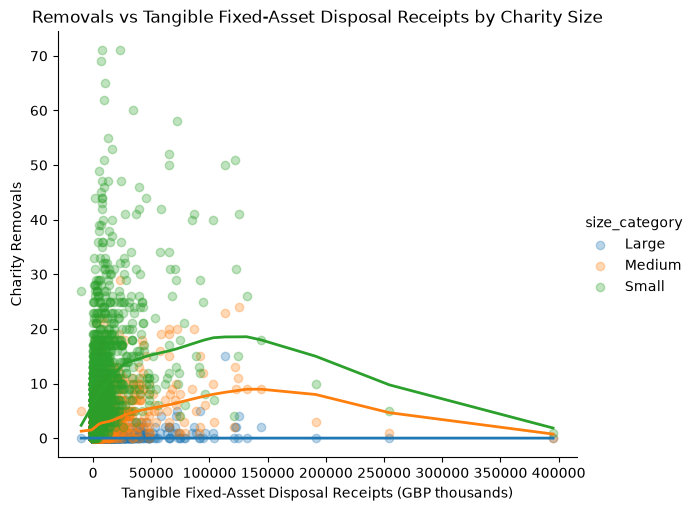

In [8]:
"""
Plot Removals vs Value by Charity Size
"""

filtered_panel_1 = filtered_panel.copy()
filtered_panel_1["value_thousands"] = filtered_panel_1["value"] * 1000

sns.lmplot(
    data=filtered_panel_1,
    x="value_thousands",
    y="removals",
    hue="size_category",  # group by charity size
    lowess=True,
    scatter_kws={"alpha": 0.3},
    line_kws={"linewidth": 2},
    height=5,
    aspect=1.2,
)

plt.xlabel("Tangible Fixed-Asset Disposal Receipts (GBP thousands)")
plt.ylabel("Charity Removals")
plt.title("Removals vs Tangible Fixed-Asset Disposal Receipts by Charity Size")
plt.show()

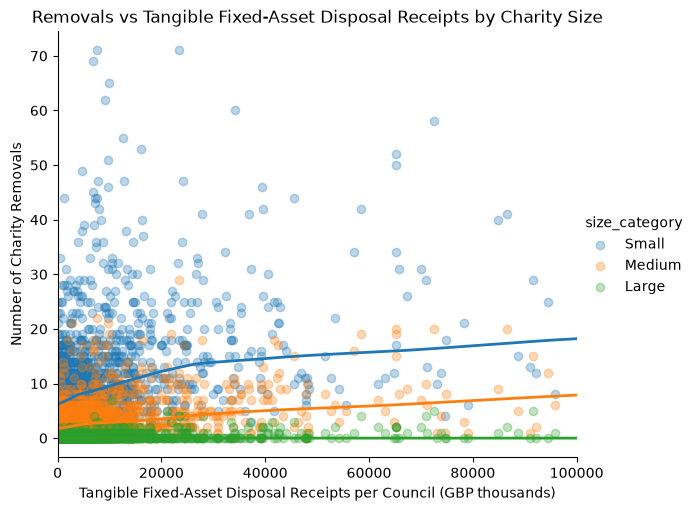

In [9]:
"""
Plot Removals vs Value by Charity Size with defined scope
"""

sns.lmplot(
    data=filtered_panel_1,
    x="value_thousands",
    y="removals",
    hue="size_category",
    hue_order=["Small", "Medium", "Large"],  # green on top, then orange, then blue
    lowess=True,
    scatter_kws={"alpha": 0.3},
    line_kws={"linewidth": 2},
    height=5,
    aspect=1.2,
)
plt.xlabel("Tangible Fixed-Asset Disposal Receipts per Council (GBP thousands)")
plt.ylabel("Number of Charity Removals")
plt.title("Removals vs Tangible Fixed-Asset Disposal Receipts by Charity Size")
plt.xlim(0, 100000)
plt.show()